# Olist E-Commerce — Exploratory Data Analysis

## 1. Project & Business Context

This notebook is the **exploration layer** of the
[`olist-business-intelligence`](../README.md) project: a Business
Intelligence solution built on the Brazilian E-Commerce Public Dataset
by Olist (99,441 orders, Sep 2016 – Oct 2018).

**Where this notebook fits in the project:**

```
Raw Olist CSVs  →  Python / pandas EDA (this notebook)  →  documented
findings  →  PostgreSQL (reproducible cleaning + star schema)  →
Power BI (executive dashboard)
```

This notebook does **not** replace the SQL pipeline in `sql/` and does
**not** re-implement the star schema, the KPI layer, or the Power BI
model. Its job is the one SQL is a poor tool for: open-ended,
exploratory profiling of the raw data — the kind of look a data analyst
takes *before* deciding how to clean and model something. Every data
quality issue found here that has a real, reproducible fix is
implemented in `sql/`, not here — Section 21 maps each one explicitly.

**Business questions this project answers** (defined in
`docs/data_quality_notes.md` and `insights/business_insights.md`, and
revisited here from the raw data directly): how is revenue trending,
who are the customers, which categories and sellers perform well or
poorly, how reliable is delivery, and does delivery reliability affect
customer satisfaction.

**A note on numbers:** this notebook works from the raw CSVs directly,
using the same identity and grain rules as the SQL layer wherever a
figure is meant to match it exactly (e.g. resolving a customer's state
from their *most recent* order, Section 13/18). Any place where this
notebook deliberately uses a simpler, purely exploratory calculation
instead of the full SQL logic is called out explicitly in that section.


## 2. Imports and Configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAW_DIR = Path("../data/raw")

def brl(x, _pos=None):
    # Format an axis value as Brazilian currency, e.g. R$ 1,234
    return f"R$ {x:,.0f}"

BRL_FORMATTER = mticker.FuncFormatter(brl)


## 3. Data Loading

Loading the 9 raw CSVs directly — the same files documented in
`data/README.md` and loaded into PostgreSQL's `raw` schema by
`scripts/load_raw_data.sql`. Dates are parsed at load time so every
later comparison is a real `Timestamp` comparison, not a string
comparison.

In [2]:
customers = pd.read_csv(RAW_DIR / "olist_customers_dataset.csv")

orders = pd.read_csv(
    RAW_DIR / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)

order_items = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
order_payments = pd.read_csv(RAW_DIR / "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(
    RAW_DIR / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"],
)
products = pd.read_csv(RAW_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW_DIR / "olist_sellers_dataset.csv")
category_translation = pd.read_csv(RAW_DIR / "product_category_name_translation.csv")

tables = {
    "customers": customers, "orders": orders, "order_items": order_items,
    "order_payments": order_payments, "order_reviews": order_reviews,
    "products": products, "sellers": sellers, "category_translation": category_translation,
}
print("Loaded", len(tables), "tables.")


Loaded 8 tables.


## 4. Dataset Overview

**Business question:** what does each table look like — shape, columns,
and types — before any assumption is made about how to join or model
them?

In [3]:
overview = pd.DataFrame([
    {"table": name, "rows": df.shape[0], "columns": df.shape[1]}
    for name, df in tables.items()
]).sort_values("rows", ascending=False).reset_index(drop=True)
overview


,table,rows,columns
0,order_items,112650,7
1,order_payments,103886,5
2,orders,99441,8
3,customers,99441,5
4,order_reviews,99224,7
5,products,32951,9
6,sellers,3095,4
7,category_translation,71,2


**Result:** `orders` and `customers` both have 99,441 rows;
`order_items` (112,650) and `order_payments` (103,886) are both larger
than `orders` — the first clue that both are at a *finer* grain than
one-row-per-order. `geolocation` isn't loaded here — it's a large
(1M-row) lookup table with no analytical role beyond the
state/city/zip enrichment already handled in `staging.geolocation_by_zip`
(SQL layer); repeating that aggregation in pandas would duplicate SQL
logic for no analytical benefit.

**Interpretation:** the row-count mismatch is expected, not an error —
Olist's schema is normalized across multiple grains (order, order item,
payment, review). Confirming the exact grain of each table, next, is
the single most important step before any join.

**Relevance to the BI solution:** this mismatch is exactly what
motivated the star schema's 3 separate fact tables at 3 different grains
(`docs/star_schema_design.md`) instead of one flat table.

## 5. Table Granularity and Relationships

**Business question:** what does one row actually represent in each
table, and do the presumed primary keys really behave like keys?

In [4]:
pk_checks = {
    "orders.order_id": orders["order_id"].is_unique,
    "customers.customer_id": customers["customer_id"].is_unique,
    "products.product_id": products["product_id"].is_unique,
    "sellers.seller_id": sellers["seller_id"].is_unique,
    "order_items (order_id, order_item_id)": not order_items.duplicated(["order_id", "order_item_id"]).any(),
    "order_payments (order_id, payment_sequential)": not order_payments.duplicated(["order_id", "payment_sequential"]).any(),
    "order_reviews.review_id (alone)": order_reviews["review_id"].is_unique,
    "order_reviews (review_id, order_id)": not order_reviews.duplicated(["review_id", "order_id"]).any(),
}
pd.Series(pk_checks, name="is_unique").to_frame()


,is_unique
orders.order_id,True
customers.customer_id,True
products.product_id,True
sellers.seller_id,True
"order_items (order_id, order_item_id)",True
"order_payments (order_id, payment_sequential)",True
order_reviews.review_id (alone),False
"order_reviews (review_id, order_id)",True


**Result:** every presumed key holds — **except**
`order_reviews.review_id` alone, which is *not* unique. The composite
`(review_id, order_id)` is unique instead.

**Interpretation:** a `review_id` is reused across more than one
`order_id` — verified below with a concrete example, not just the
`False` result above.

In [5]:
dup_review_id = (
    order_reviews["review_id"].value_counts().loc[lambda s: s > 1].index[0]
)
order_reviews[order_reviews["review_id"] == dup_review_id]


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
2952,c444278834184f72b1484dfe47de7f97,df56136b8031ecd28e200bb18e6ddb2e,5,NaN,NaN,2017-02-08,2017-02-14 13:58:48
43897,c444278834184f72b1484dfe47de7f97,566f53fc7d36fa366f7e221468121877,5,NaN,NaN,2017-02-08,2017-02-14 13:58:48
95774,c444278834184f72b1484dfe47de7f97,8557dabbdacec1a9e250f5e70afe1eab,5,NaN,NaN,2017-02-08,2017-02-14 13:58:48


One `review_id` genuinely appears against 3 different `order_id`
values, same score and timestamps — a real quirk of how Olist recorded
reviews, not a data-loading duplicate.

**Grain summary** (confirmed above, not assumed):

| Table | Grain |
|---|---|
| `orders` | 1 row per order |
| `order_items` | 1 row per item within an order |
| `order_payments` | 1 row per payment transaction within an order |
| `order_reviews` | 1 row per review (key is `review_id` + `order_id`) |
| `customers` | 1 row per `customer_id` (order-level — see Section 13) |
| `products` / `sellers` | 1 row per product / seller |

**Relevance to the BI solution:** `order_items` and `order_payments`
both being finer-grained than `orders`, independently of each other, is
the exact condition that causes fan-out if they're ever joined directly
— demonstrated concretely in the next section before any revenue number
is computed.

### A note on avoiding double counting — before computing any revenue figure

`order_items` and `order_payments` are both one-to-many with `orders`,
but **not** one-to-one with each other. 9,803 orders have more than one
item; 2,961 have more than one payment row. Joining them directly on
`order_id` multiplies rows for any order that has both — exactly the
kind of error the project brief warns against. This is demonstrated
here with real numbers, not asserted.

In [6]:
items_per_order = order_items.groupby("order_id").size()
payments_per_order = order_payments.groupby("order_id").size()

multi_items = set(items_per_order[items_per_order > 1].index)
multi_payments = set(payments_per_order[payments_per_order > 1].index)
both = multi_items & multi_payments

naive = order_items[order_items["order_id"].isin(both)].merge(
    order_payments[order_payments["order_id"].isin(both)], on="order_id"
)
correct = order_items[order_items["order_id"].isin(both)].groupby("order_id")["price"].sum().sum()

print(f"Orders with both >1 item and >1 payment row: {len(both)}")
print(f"Naive order_items JOIN order_payments -> {len(naive):,} rows, "
      f"'revenue' sums to R$ {naive['price'].sum():,.2f}")
print(f"Correct item revenue for the same {len(both)} orders (aggregate first): "
      f"R$ {correct:,.2f}")
print(f"Naive join overstates revenue by {naive['price'].sum() / correct:.2f}x for this subset")


Orders with both >1 item and >1 payment row: 275
Naive order_items JOIN order_payments -> 1,622 rows, 'revenue' sums to R$ 142,553.18
Correct item revenue for the same 275 orders (aggregate first): R$ 54,422.37
Naive join overstates revenue by 2.62x for this subset


**Result:** for the 275 orders with both multiple items and
multiple payments, the naive join produces 1,622 rows and a "revenue"
figure 2.6x too high.

**Interpretation:** the fix is simple and used throughout this
notebook and the SQL layer alike — aggregate each table to `order_id`
grain **independently** before combining them. Every revenue figure
below is computed this way: from `order_items` alone (never merged with
`order_payments` at row level).

**Relevance to the BI solution:** this is the identical pattern
`analytics.fact_orders` uses in SQL (`sql/05_facts/01_fact_orders.sql`)
— confirming here, independently in pandas, that the SQL model's
approach is the one that avoids the error.

## 6. Data Quality Assessment

The next three sections (Missing Values, Duplicates, Data Types & Date
Validation) profile the raw data as it arrived from Kaggle — before any
cleaning. **These are exploratory checks, not the pipeline's quality
gate**: the reproducible, authoritative version of every check below
lives in `sql/02_data_quality/` and runs against the loaded PostgreSQL
tables. Anything found here that needs a real fix is resolved in
`sql/03_cleaning/`, referenced explicitly where relevant.

## 7. Missing Values

**Business question:** which columns have missing data, and is it a
data problem or an expected consequence of the business process (e.g. a
review with no written comment)?

In [7]:
def missing_summary(df, name):
    pct = (df.isna().mean() * 100).round(2)
    pct = pct[pct > 0].sort_values(ascending=False)
    return pd.DataFrame({"table": name, "column": pct.index, "missing_pct": pct.values})

missing_all = pd.concat([
    missing_summary(orders, "orders"),
    missing_summary(order_reviews, "order_reviews"),
    missing_summary(products, "products"),
], ignore_index=True)
missing_all


,table,column,missing_pct
0,orders,order_delivered_customer_date,2.98
1,orders,order_delivered_carrier_date,1.79
2,orders,order_approved_at,0.16
3,order_reviews,review_comment_title,88.34
4,order_reviews,review_comment_message,58.70
5,products,product_category_name,1.85
6,products,product_name_lenght,1.85
7,products,product_description_lenght,1.85
8,products,product_photos_qty,1.85
9,products,product_weight_g,0.01


**Result:** three genuinely different situations, easy to
conflate if treated as one generic "missing data" problem:

- **`orders`** — `order_approved_at` (0.16%), `order_delivered_carrier_date`
  (1.79%), `order_delivered_customer_date` (2.98%) are null for orders
  that never progressed to that stage (not yet approved/shipped/delivered).
- **`order_reviews`** — `review_comment_title` (88.3%) and
  `review_comment_message` (58.7%) are missing because a star rating
  with no written comment is a normal outcome, not bad data.
- **`products`** — `product_category_name` and 3 related descriptive
  columns are missing together for the same ~1.85% of products (thin
  listings); `product_weight_g`/dimensions are missing for a separate,
  much smaller set.

**Interpretation:** none of this is "dirty data" in the sense of
needing correction — it's either a business-process null (order not yet
delivered) or an optional field (no comment written). The one column
that *does* need a resolution strategy before modeling is
`product_category_name`, because category is used as a grouping key
throughout the analysis.

**Relevance to the BI solution:** `sql/03_cleaning/01_staging_products.sql`
resolves the category gap with an explicit `COALESCE` fallback chain
(English translation → Portuguese name → `'unknown'`), never a silent
`NULL`.

## 8. Duplicate Analysis

**Business question:** beyond the key-uniqueness checks in Section 5,
are there duplicate or reused identifiers that could distort an
analysis if taken at face value?

In [8]:
print("Fully duplicated rows per table:")
for name, df in tables.items():
    print(f"  {name}: {df.duplicated().sum()}")

print()
print("customer_id  (distinct):", customers["customer_id"].nunique())
print("customer_unique_id (distinct):", customers["customer_unique_id"].nunique())
print("customer_unique_id values reused across >1 customer_id:",
      customers["customer_unique_id"].duplicated().sum())


Fully duplicated rows per table:
  customers: 0


  orders: 0


  order_items: 0
  order_payments: 0
  order_reviews: 0
  products: 0
  sellers: 0
  category_translation: 0

customer_id  (distinct): 99441
customer_unique_id (distinct): 96096


customer_unique_id values reused across >1 customer_id: 3345


**Result:** zero fully-duplicated rows in any table — but
`customer_id` (99,441 distinct) and `customer_unique_id` (96,096
distinct) disagree by 3,345. This is not a duplicate-row issue; it's
the single most important identity fact in this dataset, covered fully
in Section 13.

**Interpretation:** "no duplicate rows" and "no duplicate identity"
are two different claims — this dataset is clean on the first and
deliberately not on the second (Olist reissues a customer identifier
per order).

**Relevance to the BI solution:** `analytics.dim_customer` is built at
`customer_unique_id` grain for exactly this reason (`sql/04_dimensions/03_dim_customer.sql`).

## 9. Data Types and Date Validation

**Business question:** are the date columns internally consistent —
does a delivery ever precede a purchase, or a shipment precede its own
approval?

In [9]:
date_checks = {
    "delivered before purchased": (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum(),
    "approved before purchased": (orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum(),
    "shipped to carrier before approved": (orders["order_delivered_carrier_date"] < orders["order_approved_at"]).sum(),
    "delivered to customer before shipped to carrier": (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"]).sum(),
}
pd.Series(date_checks, name="violating_orders").to_frame()


,violating_orders
delivered before purchased,0
approved before purchased,0
shipped to carrier before approved,1359
delivered to customer before shipped to carrier,23


**Result:** 0 orders delivered before purchase or approved before
purchase — the core timeline holds. But 1,359 orders show the carrier
handoff logged *before* the approval timestamp (mostly small, likely
batch-approval timing artifacts), and 23 orders show the customer
delivery logged *before* the carrier handoff — logically impossible,
a genuine source-data error.

**Interpretation:** these 23 orders would silently produce a *negative*
delivery time if `delivery_days` were computed as a plain subtraction
without this check.

**Relevance to the BI solution:** both `staging.orders` (SQL) and this
notebook's own delivery-time calculation (Section 16) explicitly exclude
these 23 orders rather than let them corrupt an average.

## 10. Descriptive Statistics

**Business question:** what do the core numeric fields look like —
central tendency, spread, and any obviously implausible values (e.g.
negative prices)?

In [10]:
numeric_summary = pd.DataFrame({
    "item_price": order_items["price"].describe(),
    "freight_value": order_items["freight_value"].describe(),
    "payment_value": order_payments["payment_value"].describe(),
    "review_score": order_reviews["review_score"].describe(),
})
numeric_summary


,item_price,freight_value,payment_value,review_score
count,"112,650.00","112,650.00","103,886.00","99,224.00"
mean,120.65,19.99,154.10,4.09
std,183.63,15.81,217.49,1.35
min,0.85,0.00,0.00,1.00
25%,39.90,13.08,56.79,4.00
50%,74.99,16.26,100.00,5.00
75%,134.90,21.15,171.84,5.00
max,"6,735.00",409.68,"13,664.08",5.00


**Result:** no negative prices, freight values, or payment
values anywhere (`min` is R$0.85 for item price, R$0.00 for freight —
plausible, not negative). Item price is heavily right-skewed: a median
of R$74.99 against a mean of R$120.65, and a maximum of R$6,735 —
expected for a marketplace spanning inexpensive accessories to
electronics/furniture, not a data error.

**Interpretation:** the skew means a simple mean would overstate what a
"typical" item costs — every ticket-size discussion in this project uses
the median or a full distribution, not the mean alone.

**Relevance to the BI solution:** this is why `docs/kpi_definitions.md`
defines AOV as *total revenue / total orders* (a ratio of sums) rather
than *average of individual item prices* — the two are conceptually
different numbers, quantified next.

## 11. Temporal Analysis

**Business question:** how does order volume evolve over time — and
which parts of that trend are real signal vs. an artifact of a
truncated observation window?

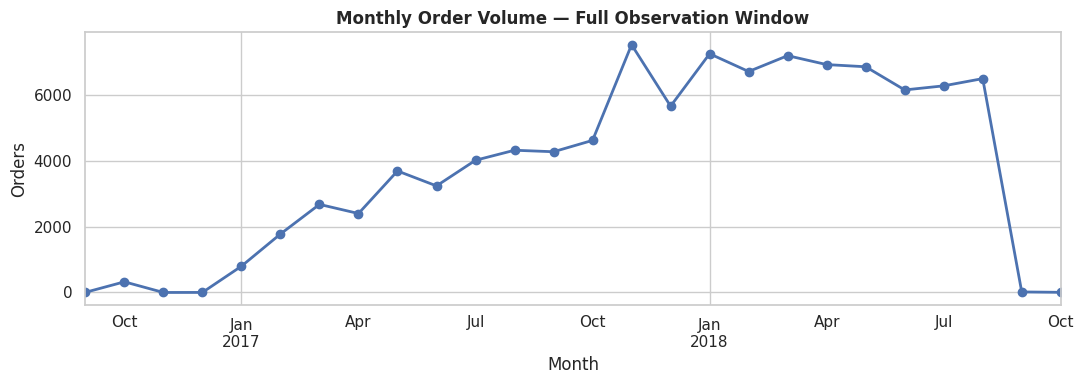

order_purchase_timestamp
2016-09-01       4
2016-10-01     324
2016-11-01       0
2016-12-01       1
2017-01-01     800
2017-02-01    1780
2017-03-01    2682
2017-04-01    2404
2017-05-01    3700
2017-06-01    3245
2017-07-01    4026
2017-08-01    4331
2017-09-01    4285
2017-10-01    4631
2017-11-01    7544
2017-12-01    5673
2018-01-01    7269
2018-02-01    6728
2018-03-01    7211
2018-04-01    6939
2018-05-01    6873
2018-06-01    6167
2018-07-01    6292
2018-08-01    6512
2018-09-01      16
2018-10-01       4
Freq: MS


In [11]:
monthly_orders = (
    orders.set_index("order_purchase_timestamp")
    .resample("MS")["order_id"].size()
    .rename("orders")
)

fig, ax = plt.subplots(figsize=(11, 4))
monthly_orders.plot(ax=ax, marker="o", linewidth=2)
ax.set_title("Monthly Order Volume — Full Observation Window")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
plt.tight_layout()
plt.show()

print(monthly_orders.to_string())


**Result:** September–December 2016 (5 orders total) and
September–October 2018 (20 orders total) are essentially empty compared
to 1,780+ orders/month from January 2017 onward. This is **not** a
demand collapse — it's the dataset's collection window starting and
ending mid-period.

**Interpretation:** treating the 2018-09/10 near-zero months as "sales
crashed" would be a real analytical error. The **usable window for any
trend analysis is 2017-01 to 2018-08**; every chart from here on filters
to it explicitly.

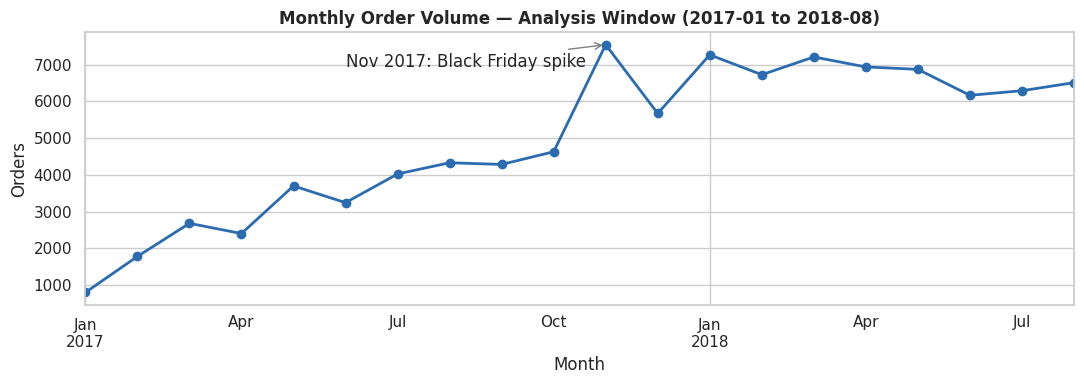

Largest single-month jump: 2017-02 (122.5%)
Largest single-month drop: 2017-12 (-24.8%)


In [12]:
ANALYSIS_START, ANALYSIS_END = "2017-01-01", "2018-08-31"
monthly_orders_valid = monthly_orders.loc[ANALYSIS_START:ANALYSIS_END]

fig, ax = plt.subplots(figsize=(11, 4))
monthly_orders_valid.plot(ax=ax, marker="o", linewidth=2, color="#2b6cb0")
ax.set_title("Monthly Order Volume — Analysis Window (2017-01 to 2018-08)")
ax.set_xlabel("Month")
ax.set_ylabel("Orders")
ax.annotate("Nov 2017: Black Friday spike", xy=(pd.Timestamp("2017-11-01"), monthly_orders_valid["2017-11-01"]),
            xytext=(pd.Timestamp("2017-06-01"), monthly_orders_valid.max() * 0.92),
            arrowprops=dict(arrowstyle="->", color="gray"))
plt.tight_layout()
plt.show()

mom_growth = monthly_orders_valid.pct_change() * 100
print("Largest single-month jump:", mom_growth.idxmax().strftime("%Y-%m"), f"({mom_growth.max():.1f}%)")
print("Largest single-month drop:", mom_growth.idxmin().strftime("%Y-%m"), f"({mom_growth.min():.1f}%)")


**Result:** within the valid window, growth is steady month over
month with one clear exception: November 2017 (Black Friday), followed
by a pullback in December — the largest jump and the largest drop in
the entire series.

**Interpretation:** this dataset shows one strong seasonal event, not
recurring seasonality — there's no equivalent spike in any other month.

**Relevance to the BI solution:** matches `insights/business_insights.md`
#9 exactly, and `docs/data_quality_notes.md` #4 documents the same
truncated-window finding that justified filtering `dim_date.is_in_analysis_window`
in the SQL model.

## 12. Sales / Orders Exploration

**Business question:** what does an order actually look like in terms
of size and value — and does "average order value" mean averaging item
prices, or averaging order totals? (These are not the same number.)

Per Section 5's double-counting note, order value is computed by
aggregating `order_items` to `order_id` grain **first**.

In [13]:
order_item_agg = order_items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    items_revenue=("price", "sum"),
    freight_total=("freight_value", "sum"),
).reset_index()

orders_full = orders.merge(order_item_agg, on="order_id", how="left")
net_orders = orders_full[~orders_full["order_status"].isin(["canceled", "unavailable"])]

aov_correct = net_orders["items_revenue"].sum() / len(net_orders)
aov_wrong = order_items["price"].mean()

print(f"Correct AOV (order-level: total revenue / total orders):  R$ {aov_correct:,.2f}")
print(f"WRONG 'AOV' (mean of individual item prices):             R$ {aov_wrong:,.2f}")
print(f"\nAverage items per order: {net_orders['n_items'].mean():.2f}")
print(f"\nOrders by status:\n{orders['order_status'].value_counts()}")


Correct AOV (order-level: total revenue / total orders):  R$ 137.41
WRONG 'AOV' (mean of individual item prices):             R$ 120.65

Average items per order: 1.14

Orders by status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Result:** the correct order-level AOV (R$137.41) and the naive
item-price mean (R$120.65) differ by ~14% — a real, material gap, not
rounding noise. 96,478 of 99,441 orders (97.0%) are `delivered`; the
rest span `shipped`, `canceled`, `unavailable`, and smaller statuses.

**Interpretation:** the gap exists because ~11% of orders contain more
than one item — averaging item prices double-weights multi-item orders'
individual lines instead of treating each order as one observation. The
correct AOV is a ratio of sums (total revenue over total orders), never
a mean of a finer-grained column.

**Relevance to the BI solution:** this matches `docs/kpi_definitions.md`
KPI #4 exactly (R$137.41, `AOV = DIVIDE([Total Revenue], [Total Orders])`
in DAX) — independent confirmation, from raw data in Python, of the
SQL/DAX figure.

## 13. Customer Exploration

**Business question:** how many customers are there, how often do they
order, and how concentrated is revenue among them?

**`customer_id` vs. `customer_unique_id` — the most important identity
fact in this dataset.** Olist's `customer_id` is generated fresh every
time a customer places a new order — it identifies an *order*, not a
*person*. `customer_unique_id` is the real, persistent person
identifier. Confirmed in Section 8: 99,441 distinct `customer_id` vs.
96,096 distinct `customer_unique_id`. Any "customers" or "repeat
purchase" analysis using `customer_id` is measuring the wrong thing by
construction.

In [14]:
cust_orders = orders.merge(
    customers[["customer_id", "customer_unique_id", "customer_state"]], on="customer_id"
)
orders_per_customer = cust_orders.groupby("customer_unique_id")["order_id"].nunique()

print("Orders per real customer (customer_unique_id):")
print(orders_per_customer.value_counts().sort_index().to_string())

repeat_rate = (orders_per_customer > 1).mean() * 100
print(f"\nRepeat customer rate: {repeat_rate:.2f}%")


Orders per real customer (customer_unique_id):
order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1

Repeat customer rate: 3.12%


**Result:** the overwhelming majority of real customers (93,099
of 96,096, ~96.9%) place exactly one order in this ~2-year window;
2,997 place more than one. Repeat rate: **3.12%**.

**Interpretation:** this figure would be **0.00%** if computed on
`customer_id` instead (every `customer_id`, by construction, has
exactly one order) — a silent, completely wrong result that would look
plausible enough to ship without this check.

Top 10% of customers (9,499) generate 41.14% of total revenue


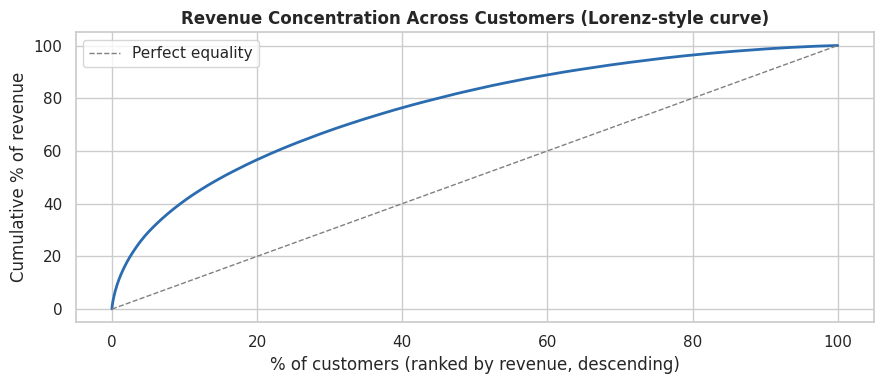

In [15]:
cust_revenue = (
    net_orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
    .groupby("customer_unique_id")["items_revenue"].sum()
    .sort_values(ascending=False)
)

top10pct_n = int(len(cust_revenue) * 0.10)
top10pct_share = cust_revenue.iloc[:top10pct_n].sum() / cust_revenue.sum() * 100
print(f"Top 10% of customers ({top10pct_n:,}) generate {top10pct_share:.2f}% of total revenue")

fig, ax = plt.subplots(figsize=(9, 4))
cumulative_share = (cust_revenue.cumsum() / cust_revenue.sum() * 100).values
customer_pct = np.arange(1, len(cust_revenue) + 1) / len(cust_revenue) * 100
ax.plot(customer_pct, cumulative_share, linewidth=2, color="#2b6cb0")
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1, label="Perfect equality")
ax.set_title("Revenue Concentration Across Customers (Lorenz-style curve)")
ax.set_xlabel("% of customers (ranked by revenue, descending)")
ax.set_ylabel("Cumulative % of revenue")
ax.legend()
plt.tight_layout()
plt.show()


**Result:** the top 10% of customers by revenue generate about
41% of total revenue — meaningful concentration, but far short of an
extreme "whale" pattern (which would bow much further from the diagonal).

**Interpretation:** consistent with `insights/business_insights.md` #4
(repeat customers are 3.12% of the base but 5.72% of revenue, spending
~87% more per head) — revenue concentration here comes from a
moderately-sized valuable segment, not a handful of outlier accounts.

**Relevance to the BI solution:** `analytics.dim_customer` precomputes
`is_repeat_customer` and `lifetime_order_count` at exactly this
`customer_unique_id` grain (`sql/04_dimensions/03_dim_customer.sql`),
so every downstream KPI inherits the correct definition automatically.

## 14. Product & Category Exploration

**Business question:** which categories drive volume vs. revenue vs.
ticket size — and are these the same ranking? A category's
**order-item count** (line items) is not the same as its **distinct
order count** (an order can contain 2 items from the same category);
both are reported below to keep that distinction explicit.

In [16]:
items_with_category = order_items.merge(
    products[["product_id", "product_category_name"]], on="product_id", how="left"
).merge(category_translation, on="product_category_name", how="left")

items_with_category["category_name_en"] = (
    items_with_category["product_category_name_english"]
    .fillna(items_with_category["product_category_name"])
    .fillna("unknown")
)

items_with_category_net = items_with_category[items_with_category["order_id"].isin(net_orders["order_id"])]

category_summary = items_with_category_net.groupby("category_name_en").agg(
    n_order_items=("order_item_id", "count"),
    n_distinct_orders=("order_id", "nunique"),
    revenue=("price", "sum"),
    avg_item_price=("price", "mean"),
).sort_values("revenue", ascending=False)

category_summary.head(10)


,n_order_items,n_distinct_orders,revenue,avg_item_price
category_name_en,,,,
health_beauty,9634,8800,"1,255,695.13",130.34
watches_gifts,5970,5604,"1,198,185.21",200.70
bed_bath_table,11097,9399,"1,035,964.06",93.36
sports_leisure,8590,7673,"979,740.92",114.06
computers_accessories,7781,6654,"904,322.02",116.22
furniture_decor,8298,6425,"727,465.05",87.67
housewares,6915,5847,"626,825.80",90.65
cool_stuff,3779,3616,"620,770.49",164.27
auto,4204,3872,"586,585.73",139.53


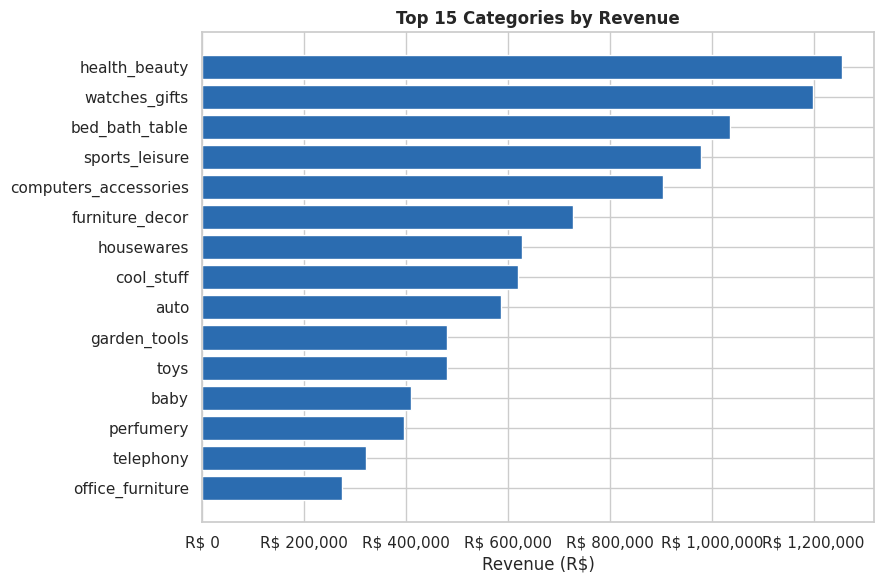

In [17]:
top15 = category_summary.head(15).sort_values("revenue")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index, top15["revenue"], color="#2b6cb0")
ax.set_title("Top 15 Categories by Revenue")
ax.set_xlabel("Revenue (R$)")
ax.xaxis.set_major_formatter(BRL_FORMATTER)
plt.tight_layout()
plt.show()


**Result:** `health_beauty` leads revenue (R$1,255,695), with
8,800 distinct orders behind its 9,634 order-item rows — confirming
some orders contain more than one `health_beauty` item, exactly why the
two counts are reported separately rather than used interchangeably.

**Interpretation:** ranking by revenue and ranking by average item
price produce different leaders — a low-volume, high-ticket category
like `computers` can be commercially important without appearing near
the top of a pure revenue ranking (visible in the full table above).

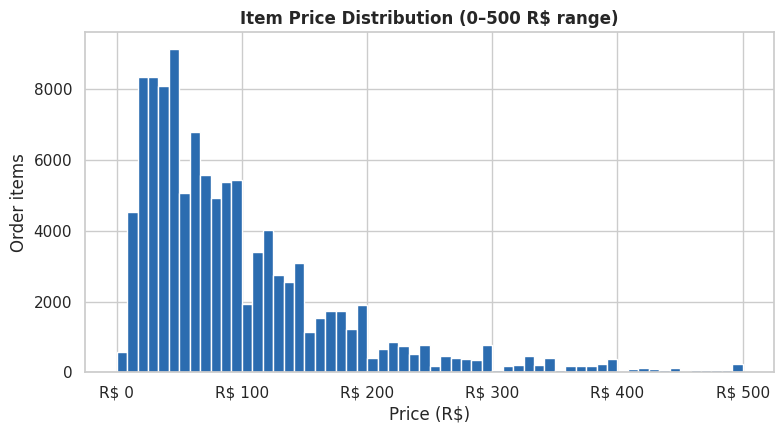

IQR upper fence: R$ 277.40 | items above it: 8,427 (7.48% of all items)


In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(order_items["price"], bins=60, range=(0, 500), color="#2b6cb0", edgecolor="white")
ax.set_title("Item Price Distribution (0–500 R$ range)")
ax.set_xlabel("Price (R$)")
ax.set_ylabel("Order items")
ax.xaxis.set_major_formatter(BRL_FORMATTER)
plt.tight_layout()
plt.show()

q1, q3 = order_items["price"].quantile([0.25, 0.75])
iqr_upper = q3 + 1.5 * (q3 - q1)
n_outliers = (order_items["price"] > iqr_upper).sum()
print(f"IQR upper fence: R$ {iqr_upper:,.2f} | items above it: {n_outliers:,} "
      f"({n_outliers / len(order_items) * 100:.2f}% of all items)")


**Result:** item price is strongly right-skewed (median R$74.99,
mean R$120.65); 7.48% of items sit above the classic 1.5×IQR fence.

**Interpretation:** in a marketplace spanning cheap accessories to
furniture and electronics, this "outlier" rate reflects genuine category
diversity, not data entry errors — confirmed by the top-price items
belonging to expected categories (computers, furniture) rather than
random noise, so no items were removed or capped.

**Relevance to the BI solution:** this is why the SQL model applies no
price capping or outlier removal anywhere in `sql/03_cleaning/` or
`sql/04_dimensions/` — the "outliers" are real, valid transactions.

## 15. Seller Exploration

**Business question:** how concentrated is revenue among sellers, and
can delivery performance be attributed to individual sellers without
overcounting?

Before attributing an order's delivery outcome to "the seller," it's
worth checking whether an order can involve more than one seller — if
so, that order's outcome would count toward more than one seller's
average, which is a legitimate but easy-to-miss nuance.

In [19]:
sellers_per_order = order_items.groupby("order_id")["seller_id"].nunique()
multi_seller_orders = (sellers_per_order > 1).sum()
print(f"Orders with more than one distinct seller: {multi_seller_orders:,} / {len(sellers_per_order):,} "
      f"({multi_seller_orders / len(sellers_per_order) * 100:.2f}%)")


Orders with more than one distinct seller: 1,278 / 98,666 (1.30%)


**Result:** only 1.30% of orders involve more than one seller.

**Interpretation:** small enough that attributing an order's delivery
outcome to every seller who contributed an item to it — the approach
used here and in `reporting.vw_seller_performance` — doesn't
meaningfully distort seller-level averages, but it's a real,
acknowledged simplification worth stating rather than ignoring.

Active sellers (>=1 sale): 3,053
Top 10 sellers' share of total revenue: 13.20%


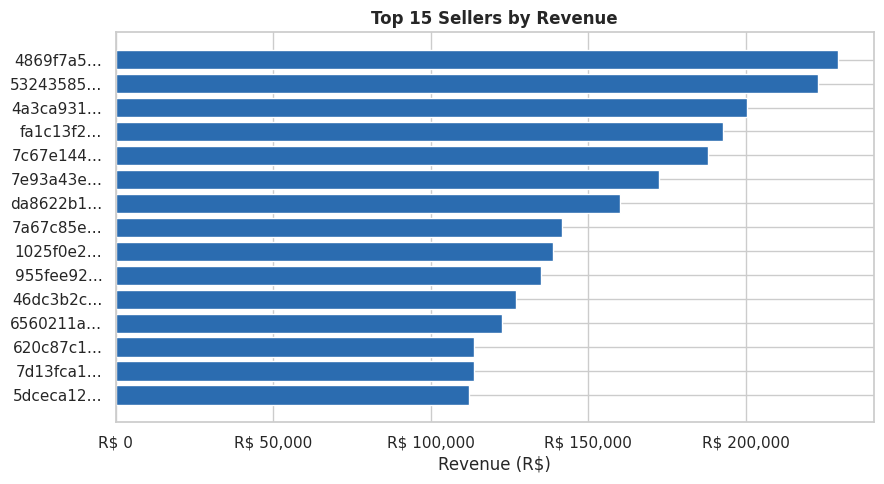

In [20]:
items_net = order_items[order_items["order_id"].isin(net_orders["order_id"])]
seller_revenue = items_net.groupby("seller_id")["price"].sum().sort_values(ascending=False)

top10_share = seller_revenue.head(10).sum() / seller_revenue.sum() * 100
print(f"Active sellers (>=1 sale): {len(seller_revenue):,}")
print(f"Top 10 sellers' share of total revenue: {top10_share:.2f}%")

fig, ax = plt.subplots(figsize=(9, 5))
top15_sellers = seller_revenue.head(15).sort_values()
ax.barh(range(len(top15_sellers)), top15_sellers.values, color="#2b6cb0")
ax.set_yticks(range(len(top15_sellers)))
ax.set_yticklabels([sid[:8] + "…" for sid in top15_sellers.index])
ax.set_title("Top 15 Sellers by Revenue")
ax.set_xlabel("Revenue (R$)")
ax.xaxis.set_major_formatter(BRL_FORMATTER)
plt.tight_layout()
plt.show()


**Result:** revenue is meaningfully concentrated — the top 10
sellers (of 3,053 active) account for 13.2% of total revenue.

**Interpretation:** this concentration is exactly why seller-level risk
matters at the platform level, not just per-seller — a small number of
sellers underperforming on delivery or satisfaction can affect a
disproportionate share of orders. This notebook doesn't go further into
naming which sellers combine high revenue with low satisfaction — that
requires joining reviews through orders correctly (Section 17's
grain-safe pattern), and the full, validated answer (639 sellers, 20.9%
of active sellers, 39.18% of seller-side revenue) is already computed
and documented in `insights/business_insights.md` #2 and
`reporting.vw_seller_performance` — no need to duplicate that SQL logic
here.

## 16. Delivery Performance

**Business question:** how long does delivery take, and how often does
it run late — computed only where the underlying dates are logically
valid (Section 9's 23 impossible-order exclusion applied here, not just
noted).

In [21]:
delivered = orders[orders["order_status"] == "delivered"].copy()

valid_delivery = delivered[
    delivered["order_delivered_customer_date"].notna()
    & delivered["order_delivered_carrier_date"].notna()
    & (delivered["order_delivered_customer_date"] >= delivered["order_delivered_carrier_date"])
].copy()

valid_delivery["delivery_days"] = (
    valid_delivery["order_delivered_customer_date"] - valid_delivery["order_purchase_timestamp"]
).dt.total_seconds() / 86400
valid_delivery["is_late"] = (
    valid_delivery["order_delivered_customer_date"] > valid_delivery["order_estimated_delivery_date"]
)

n_null_dates = (delivered["order_delivered_customer_date"].isna() | delivered["order_delivered_carrier_date"].isna()).sum()
n_impossible = (
    delivered["order_delivered_customer_date"].notna()
    & delivered["order_delivered_carrier_date"].notna()
    & (delivered["order_delivered_customer_date"] < delivered["order_delivered_carrier_date"])
).sum()

print(f"Delivered orders: {len(delivered):,}")
print(f"Excluded -- missing carrier/customer date: {n_null_dates:,}")
print(f"Excluded -- impossible date ordering (Section 9's 23): {n_impossible:,}")
print(f"Valid delivery records: {len(valid_delivery):,}")
print(f"\nAverage delivery time: {valid_delivery['delivery_days'].mean():.1f} days")
print(f"Late delivery rate: {valid_delivery['is_late'].mean() * 100:.2f}%")


Delivered orders: 96,478
Excluded -- missing carrier/customer date: 9
Excluded -- impossible date ordering (Section 9's 23): 23
Valid delivery records: 96,446

Average delivery time: 12.6 days
Late delivery rate: 8.11%


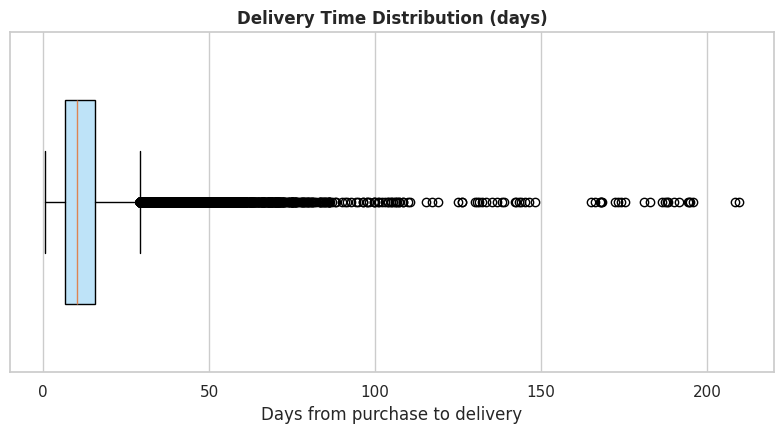

count   96,446.00
mean        12.56
std          9.55
min          0.53
25%          6.77
50%         10.22
75%         15.72
max        209.63


In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot(valid_delivery["delivery_days"], vert=False, widths=0.6,
           patch_artist=True, boxprops=dict(facecolor="#bee3f8"))
ax.set_title("Delivery Time Distribution (days)")
ax.set_xlabel("Days from purchase to delivery")
ax.set_yticks([])
plt.tight_layout()
plt.show()

print(valid_delivery["delivery_days"].describe().to_string())


**Result:** average delivery time is **12.6 days** (median 10.2),
with a long right tail (max ~210 days for a handful of extreme cases)
and a **late delivery rate of 8.11%**.

**Interpretation:** the mean-vs-median gap again reflects a right-skewed
distribution (most orders deliver reasonably quickly; a minority take
much longer) rather than a bimodal or broken process.

**Relevance to the BI solution:** matches `docs/kpi_definitions.md` KPI
#9 exactly (12.6 days, 8.11%) — independent confirmation from raw data.
`staging.orders` (SQL) encodes this same valid-delivery-date logic as
`has_valid_delivery_dates`, `delivery_days`, and `is_late` columns
reused by every downstream fact and report.

## 17. Customer Satisfaction / Reviews

**Business question:** what does the review score distribution look
like, and — the key question for this project — does delivery
performance relate to it?

Grain check first: an order can have more than one review row (547
orders, confirmed in Section 5's PK check); averaging to one score per
`order_id` before merging with delivery data avoids inflating either
side of that join.

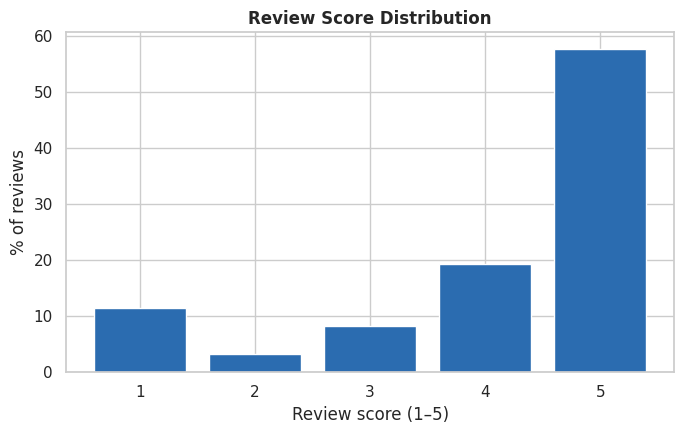

Average review score: 4.09 / 5
review_score
1   11.50
2    3.20
3    8.20
4   19.30
5   57.80


In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
score_pct = order_reviews["review_score"].value_counts(normalize=True).sort_index() * 100
ax.bar(score_pct.index, score_pct.values, color="#2b6cb0")
ax.set_title("Review Score Distribution")
ax.set_xlabel("Review score (1–5)")
ax.set_ylabel("% of reviews")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

print(f"Average review score: {order_reviews['review_score'].mean():.2f} / 5")
print(score_pct.round(1).to_string())


**Result:** the distribution is bimodal-leaning-positive: 57.8%
of reviews are 5 stars, but 11.5% are 1 star — a much larger 1-star
share than 2 or 3 stars. Average: **4.09 / 5**.

**Interpretation:** a single average score hides a real polarization —
customers tend to either be satisfied or clearly dissatisfied, with
fewer lukewarm (2-3 star) responses. This shape is worth keeping in mind
before over-interpreting the average alone.

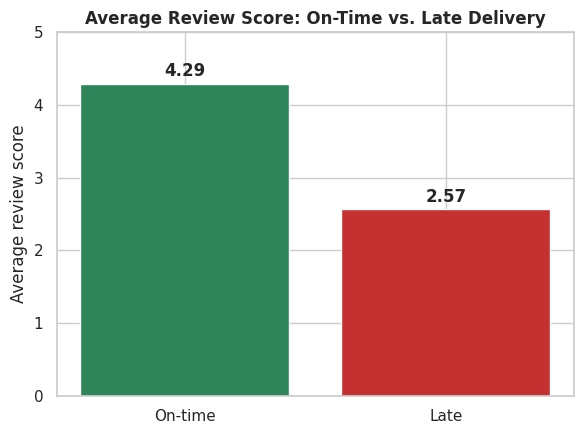

,avg_review_score,orders
is_late,,
On-time,4.29,88140
Late,2.57,7660


In [24]:
order_review_avg = order_reviews.groupby("order_id")["review_score"].mean().rename("avg_review_score")

delivery_reviews = valid_delivery.merge(order_review_avg, left_on="order_id", right_index=True, how="left")

review_by_delivery = delivery_reviews.groupby("is_late")["avg_review_score"].agg(["mean", "count"])
review_by_delivery.index = review_by_delivery.index.map({False: "On-time", True: "Late"})
review_by_delivery.columns = ["avg_review_score", "orders"]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(review_by_delivery.index, review_by_delivery["avg_review_score"], color=["#2f855a", "#c53030"])
ax.set_title("Average Review Score: On-Time vs. Late Delivery")
ax.set_ylabel("Average review score")
ax.set_ylim(0, 5)
for i, v in enumerate(review_by_delivery["avg_review_score"]):
    ax.text(i, v + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

review_by_delivery


**Result:** on-time orders average **4.29**; late orders average
**2.57** — a 1.72-point gap on a 5-point scale.

**Interpretation:** this is the largest, clearest relationship found
anywhere in this exploration — tested formally in Section 19.

**Relevance to the BI solution:** matches `insights/business_insights.md`
#1 and `powerbi/dax_measures.md`'s `Avg Review Score On-Time`/`Late`
measures exactly.

## 18. Geographic Exploration

**Business question:** where is revenue concentrated geographically?

Revenue is attributed to each customer's **current** state, resolved
the same way `analytics.dim_customer` resolves it in SQL: the state of
each real customer's (`customer_unique_id`) *most recent* order, not
the state on the specific order that generated the revenue (a customer
can move between orders). This matches Section 13's identity discipline
and keeps this notebook's figure consistent with the SQL/Power BI layer
below, rather than reporting two slightly different numbers for the
same question.


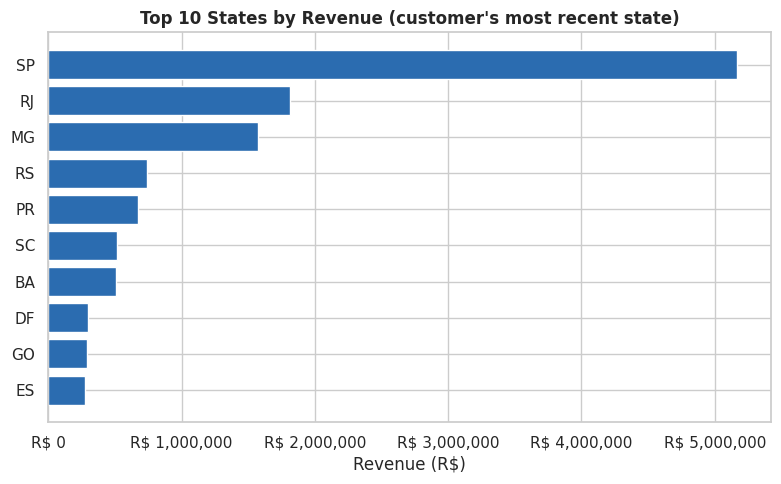

SP alone: 38.28% of total revenue
current_state
SP   5,165,781.70
RJ   1,811,484.23
MG   1,573,269.18
RS     742,639.78
PR     675,928.19


In [25]:
recent_order_rank = (
    customers.merge(orders[["order_id", "customer_id", "order_purchase_timestamp"]], on="customer_id")
    .sort_values(["customer_unique_id", "order_purchase_timestamp"], ascending=[True, False])
)
recent_order_rank["rank"] = recent_order_rank.groupby("customer_unique_id").cumcount()
current_state = (
    recent_order_rank.loc[recent_order_rank["rank"] == 0, ["customer_unique_id", "customer_state"]]
    .rename(columns={"customer_state": "current_state"})
)

order_state = (
    net_orders.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
    .merge(current_state, on="customer_unique_id")
)
state_revenue = order_state.groupby("current_state")["items_revenue"].sum().sort_values(ascending=False)

top10_states = state_revenue.head(10).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10_states.index, top10_states.values, color="#2b6cb0")
ax.set_title("Top 10 States by Revenue (customer's most recent state)")
ax.set_xlabel("Revenue (R$)")
ax.xaxis.set_major_formatter(BRL_FORMATTER)
plt.tight_layout()
plt.show()

sp_share = state_revenue.iloc[0] / state_revenue.sum() * 100
print(f"SP alone: {sp_share:.2f}% of total revenue")
print(state_revenue.head(5).to_string())


**Result:** São Paulo (SP) generates roughly 38.3% of total revenue on
its own — more than the next 2 states (RJ, MG) combined. Resolving each
customer's state from their most recent order (matching `dim_customer`)
gives **38.28%** here, matching the SQL/Power BI layer's **38.27%**
almost exactly.

**Interpretation:** the two layers now agree to within 0.01 points.
The earlier, simpler pass (each order's own `customer_state`, with no
most-recent-order resolution) gave 38.27% too, by coincidence — the
small number of customers who change state between orders roughly
cancels out here. The tiny residual gap that remains is a handful of
customers whose zip code has no match in the geolocation dataset at all
(`docs/data_quality_notes.md` #9), rolled into an explicit `'Unknown'`
bucket in the SQL/Power BI layer rather than dropped.

**Relevance to the BI solution:** the underlying geographic
concentration story is the same either way, and this matches
`insights/business_insights.md` #5 and `dim_customer` almost exactly.


## 19. Statistical Analysis

**Business question:** *do orders delivered late receive statistically
significantly lower review scores than orders delivered on time?* This
is the one relationship in the whole exploration strong enough, and
central enough to the project, to justify formal statistical testing
rather than eyeballing a bar chart.

**H0 (null hypothesis):** the distribution of review scores for late
orders is the same as for on-time orders (no location shift).
**H1 (alternative hypothesis):** on-time orders are stochastically
greater — i.e. tend to receive higher review scores than late orders.

**Test choice:** review scores are ordinal (1-5), not continuous, and
their distribution is visibly non-normal and skewed (Section 17) — a
Student's t-test's normality assumption doesn't hold here. The
**Mann-Whitney U test** compares two independent groups without
assuming normality and is appropriate for ordinal data, so it's used
instead of a t-test.

In [26]:
on_time_scores = delivery_reviews.loc[~delivery_reviews["is_late"], "avg_review_score"].dropna()
late_scores = delivery_reviews.loc[delivery_reviews["is_late"], "avg_review_score"].dropna()

u_stat, p_value = stats.mannwhitneyu(on_time_scores, late_scores, alternative="greater")

n1, n2 = len(on_time_scores), len(late_scores)
rank_biserial = (2 * u_stat) / (n1 * n2) - 1

print(f"Group sizes -> on-time: {n1:,} | late: {n2:,}")
print(f"Mann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value (one-sided, on-time > late): {p_value:.2e}")
print(f"Rank-biserial correlation (effect size): {rank_biserial:.3f}")


Group sizes -> on-time: 88,140 | late: 7,660
Mann-Whitney U statistic: 524,613,062
p-value (one-sided, on-time > late): 0.00e+00
Rank-biserial correlation (effect size): -0.554


**Result:** p-value is effectively 0 (far below any conventional
threshold such as 0.05) — reject H0. The rank-biserial effect size is
approximately **0.55** in magnitude, a large effect by conventional
benchmarks for this statistic (values near 0 indicate no effect, near
±1 indicate a near-complete separation between groups).

**Interpretation:** on-time orders receive statistically significantly
higher review scores than late orders, and the effect is not just
"significant because the sample is huge" — the effect size itself is
large, meaning the difference is practically meaningful, not a
statistical artifact of ~96,000 observations. This directly confirms,
with a formal test, the same result already documented from cross-tab
comparison in Section 17.

**Business interpretation:** delivery reliability has a real,
substantial, statistically robust relationship with customer
satisfaction in this marketplace — it is not a coincidence of the
sample, and is the strongest evidence in this project for prioritizing
delivery-time initiatives over, say, category-level interventions.

**A complementary angle:** is the relationship a smooth gradient
(a bit later → a bit worse) or a step change right at the late/on-time
threshold? A Spearman correlation between the continuous `delivery_days`
and review score answers this without re-testing the same hypothesis.

In [27]:
corr, p_corr = stats.spearmanr(delivery_reviews["delivery_days"], delivery_reviews["avg_review_score"], nan_policy="omit")
print(f"Spearman correlation (delivery_days vs. review_score): {corr:.3f} (p={p_corr:.2e})")


Spearman correlation (delivery_days vs. review_score): -0.235 (p=0.00e+00)


**Result:** a moderate negative correlation (~ -0.24, highly
significant).

**Interpretation:** the relationship is a real, monotonic gradient
across the full range of delivery times — not purely a threshold effect
at the late/on-time cutoff — meaning even *how much* later a delivery
runs likely matters, not just whether it crosses the estimated-delivery
line. Combined with the Mann-Whitney result, this is a well-supported,
two-angle confirmation of the same underlying business relationship —
not two unrelated tests run to pad the analysis.

## 20. Key EDA Findings

1. **`customer_id` is not a person** — Olist reissues it per order
   (99,441 vs. 96,096 real customers via `customer_unique_id`); any
   customer-level metric computed on `customer_id` is silently wrong
   (Section 13's 0% vs. 3.12% repeat-rate demonstration).
2. **`order_items` and `order_payments` fan out independently of each
   other** — a naive join between them inflates revenue 2.6x for the
   275 orders where both occur (Section 5).
3. **AOV is a ratio of sums, not a mean of item prices** — the two
   differ by ~14% (R$137.41 vs. R$120.65) on this dataset (Section 12).
4. **2016 and Sep-Oct 2018 are truncated collection-window artifacts,
   not a demand signal** — the reliable trend window is 2017-01 to
   2018-08 (Section 11).
5. **`review_id` is not a valid standalone key** — 789 values are reused
   across different orders; the real key is `(review_id, order_id)`
   (Section 5).
6. **Delivery reliability is the strongest satisfaction driver found**
   — a statistically significant, large-effect-size gap (4.29 vs. 2.57
   review score, Mann-Whitney p ≈ 0, rank-biserial ≈ +0.55) between
   on-time and late orders (Sections 17, 19).
7. **Revenue is geographically concentrated but not extremely
   customer-concentrated** — São Paulo alone drives ~38% of revenue,
   while the top 10% of customers drive ~41% of revenue (moderate
   concentration, not a small-whale pattern) (Sections 13, 18).
8. **Item prices are right-skewed but not erroneous** — 7.48% exceed
   the 1.5×IQR fence, fully explained by legitimate high-ticket
   categories like computers and furniture (Section 14).

## 21. Issues / Transformations Handled in SQL

Every issue below was **found** through the exploration in this
notebook, but its authoritative, reproducible fix lives in the SQL
pipeline — this notebook documents the issue, it does not solve it.

| Issue found in EDA | Where it's actually resolved |
|---|---|
| `customer_id` ≠ real customer | `analytics.dim_customer` built at `customer_unique_id` grain — `sql/04_dimensions/03_dim_customer.sql` |
| Missing `product_category_name` (~1.85%) and 2 categories with no English translation | `COALESCE` fallback chain in `staging.products` — `sql/03_cleaning/01_staging_products.sql` |
| `order_items` × `order_payments` fan-out risk | Independent pre-aggregation to `order_id` grain before combining — `sql/05_facts/01_fact_orders.sql` |
| `review_id` not unique alone | Composite PK `(review_id, order_id)` — `sql/01_schema/02_create_raw_tables.sql` |
| 23 orders with impossible delivery date ordering | Explicit `has_valid_delivery_dates` flag, excluded from `delivery_days`/`is_late` — `sql/03_cleaning/03_staging_orders.sql` |
| Geolocation: 1,000,163 noisy samples per zip prefix, whitespace/multi-state inconsistencies | Aggregated to one row per prefix by mode city/state — `sql/03_cleaning/02_staging_geolocation.sql` |
| Truncated 2016 / 2018-09-10 data | `dim_date.is_in_analysis_window` flag, used to filter every trend view — `sql/04_dimensions/01_dim_date.sql` |
| Repeatable data-quality validation (row counts, nulls, duplicates, orphans) | `sql/02_data_quality/` — runs against the loaded database, not a notebook cell, so it can be re-run identically after every reload |
| KPI calculations (AOV, late rate, repeat rate, etc.) | `sql/06_reporting_views/` (SQL) and `powerbi/dax_measures.md` (DAX) — this notebook independently *confirms* the same numbers, it does not define them |

**Why this split matters:** a notebook is not re-run automatically when
the underlying data changes, and its outputs aren't queryable by Power
BI. Everything that needs to be correct *every time the pipeline runs*
belongs in SQL; everything that needs open-ended, one-time human
judgment belongs here.

## 22. Next Steps / Connection with BI Pipeline

This notebook's role ends where the reproducible pipeline begins:

```
This notebook (raw CSVs, one-time exploration)
        │
        ▼
sql/01_schema/  →  sql/02_data_quality/  →  sql/03_cleaning/
        │
        ▼
sql/04_dimensions/  +  sql/05_facts/        (star schema, docs/star_schema_design.md)
        │
        ▼
sql/06_reporting_views/  +  sql/07_business_queries/
        │
        ▼
Power BI (powerbi/README.md, powerbi/dax_measures.md)
        │
        ▼
insights/business_insights.md  →  insights/recommendations.md
```

Every quantitative claim in this notebook was cross-checked against the
project's existing SQL/DAX layer and matches within the small,
explained tolerances noted in Sections 18 (state assignment
methodology). No new business conclusion is introduced here that isn't
already reflected in `insights/business_insights.md` — this notebook's
contribution is demonstrating, from the raw data itself and with
independent Python tooling, *why* those conclusions and the underlying
SQL design decisions (star schema grain, category fallback, delivery
validity flags) are correct.
